# Chapter 8 Figures for Frigate

This notebook generates report-ready Chapter 8 figures from the real evaluation artifacts already stored in the repository.

Output folder:
- `guidelines/figures/chapter8`

Figures produced:
- Figure 8.1 Prompt segmentation model comparison
- Figure 8.2 Segmentation label distribution
- Figure 8.3 Score-model MAE on the large labeled test split
- Figure 8.4 Score-model MAE on the reviewed gold set
- Figure 8.5 Frontend build verification summary
- Figure 8.7 Score Model Mean MAE — Large Split vs Gold Set
- Figure 8.8 Score Model Mean RMSE Comparison


## 1. Setup

If needed, install the packages first:

```bash
pip install jupyter matplotlib seaborn pandas
```


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 140
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'training' / 'artifacts').exists() and (candidate / 'guidelines').exists():
            return candidate
    raise FileNotFoundError('Could not locate the Frigate project root from the current notebook directory.')

ROOT = find_project_root(Path.cwd())

ARTIFACTS = ROOT / 'training' / 'artifacts'
OUTPUT = ROOT / 'guidelines' / 'figures' / 'chapter8'
OUTPUT.mkdir(parents=True, exist_ok=True)

def read_json(name: str):
    return json.loads((ARTIFACTS / name).read_text(encoding='utf-8'))

print('Project root:', ROOT)
print('Artifacts:', ARTIFACTS)
print('Output:', OUTPUT)


Project root: C:\Users\USER\Documents\frigate
Artifacts: C:\Users\USER\Documents\frigate\training\artifacts
Output: C:\Users\USER\Documents\frigate\guidelines\figures\chapter8


In [2]:
heuristic_segmenter = read_json('heuristic_segmenter_metrics_test.json')
epoch1_segmenter = read_json('segmenter_metrics_epoch1-baseline_test.json')
epoch3_segmenter = read_json('segmenter_metrics_epoch3-overnight.json')
segmentation_labels = read_json('segmentation_label_analysis.json')

heuristic_test = read_json('score_metrics_heuristic_test.json')
linear_test = read_json('score_metrics_manifest_linear_test.json')
heuristic_gold = read_json('score_metrics_heuristic_gold_test.json')
linear_gold = read_json('score_metrics_manifest_linear_gold_test.json')
distilbert_test = read_json('score_regressor_metrics_distilbert-v1.json')
distilbert_gold = read_json('score_regressor_metrics_distilbert-gold-cpu.json')

build_check = read_json('frontend_build_check_2026-04-02.json')


## 2. Real Metrics Tables for the Report

Run the next two cells to display the exact values you can copy into Chapter 8.

In [3]:
segmentation_table = pd.DataFrame([
    {
        'Experiment': 'S1',
        'Model / Approach': 'Heuristic segmenter baseline',
        'Accuracy': heuristic_segmenter['eval_accuracy'],
        'Precision': heuristic_segmenter['eval_precision'],
        'Recall': heuristic_segmenter['eval_recall'],
        'F1-score': heuristic_segmenter['eval_f1'],
    },
    {
        'Experiment': 'S2',
        'Model / Approach': 'DistilBERT segmenter, epoch 1 baseline',
        'Accuracy': epoch1_segmenter['eval_accuracy'],
        'Precision': epoch1_segmenter['eval_precision'],
        'Recall': epoch1_segmenter['eval_recall'],
        'F1-score': epoch1_segmenter['eval_f1'],
    },
    {
        'Experiment': 'S3',
        'Model / Approach': 'DistilBERT segmenter, epoch 3 overnight',
        'Accuracy': epoch3_segmenter['eval_accuracy'],
        'Precision': epoch3_segmenter['eval_precision'],
        'Recall': epoch3_segmenter['eval_recall'],
        'F1-score': epoch3_segmenter['eval_f1'],
    },
])

score_test_table = pd.DataFrame([
    {
        'Experiment': 'R2',
        'Model / Approach': 'Manifest linear scorer',
        'Trust MAE': linear_test['trust_mae'],
        'Clarity MAE': linear_test['clarity_mae'],
        'Quality MAE': linear_test['quality_mae'],
        'Mean MAE': linear_test['mae_mean'],
        'Mean RMSE': linear_test['rmse_mean'],
        'Mean Pearson': None,
    },
    {
        'Experiment': 'R3',
        'Model / Approach': 'DistilBERT regressor',
        'Trust MAE': distilbert_test['trust_mae'],
        'Clarity MAE': distilbert_test['clarity_mae'],
        'Quality MAE': distilbert_test['quality_mae'],
        'Mean MAE': distilbert_test['mae_mean'],
        'Mean RMSE': distilbert_test['rmse_mean'],
        'Mean Pearson': distilbert_test.get('pearson_mean'),
    },
])

gold_table = pd.DataFrame([
    {
        'Experiment': 'G1',
        'Model / Approach': 'Heuristic scorer',
        'Trust MAE': heuristic_gold['trust_mae'],
        'Clarity MAE': heuristic_gold['clarity_mae'],
        'Quality MAE': heuristic_gold['quality_mae'],
        'Mean MAE': heuristic_gold['mae_mean'],
        'Mean RMSE': heuristic_gold['rmse_mean'],
        'Mean Pearson': None,
    },
    {
        'Experiment': 'G2',
        'Model / Approach': 'Manifest linear scorer',
        'Trust MAE': linear_gold['trust_mae'],
        'Clarity MAE': linear_gold['clarity_mae'],
        'Quality MAE': linear_gold['quality_mae'],
        'Mean MAE': linear_gold['mae_mean'],
        'Mean RMSE': linear_gold['rmse_mean'],
        'Mean Pearson': None,
    },
    {
        'Experiment': 'G3',
        'Model / Approach': 'DistilBERT regressor',
        'Trust MAE': distilbert_gold['trust_mae'],
        'Clarity MAE': distilbert_gold['clarity_mae'],
        'Quality MAE': distilbert_gold['quality_mae'],
        'Mean MAE': distilbert_gold['mae_mean'],
        'Mean RMSE': distilbert_gold['rmse_mean'],
        'Mean Pearson': distilbert_gold.get('pearson_mean'),
    },
])

segmentation_table_rounded = segmentation_table.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
    segmentation_table_rounded[col] = segmentation_table_rounded[col].map(lambda x: round(x, 4))

score_test_table_rounded = score_test_table.copy()
for col in ['Trust MAE', 'Clarity MAE', 'Quality MAE', 'Mean MAE', 'Mean RMSE', 'Mean Pearson']:
    score_test_table_rounded[col] = score_test_table_rounded[col].map(lambda x: None if pd.isna(x) else round(x, 4))

gold_table_rounded = gold_table.copy()
for col in ['Trust MAE', 'Clarity MAE', 'Quality MAE', 'Mean MAE', 'Mean RMSE', 'Mean Pearson']:
    gold_table_rounded[col] = gold_table_rounded[col].map(lambda x: None if pd.isna(x) else round(x, 4))


In [4]:
print('Table 8.1: Prompt segmentation experiments')
display(segmentation_table_rounded)

print('Table 8.2: Score-model experiments on the large labeled test split')
display(score_test_table_rounded)

print('Table 8.3: Gold-set score-model evaluation')
display(gold_table_rounded)

segmentation_table_rounded.to_csv(OUTPUT / 'table-8-1-segmentation-metrics.csv', index=False)
score_test_table_rounded.to_csv(OUTPUT / 'table-8-2-score-test-metrics.csv', index=False)
gold_table_rounded.to_csv(OUTPUT / 'table-8-3-score-gold-metrics.csv', index=False)

print('Saved CSV tables to:', OUTPUT)


Table 8.1: Prompt segmentation experiments


,Experiment,Model / Approach,Accuracy,Precision,Recall,F1-score
0,S1,Heuristic segmenter baseline,0.8465,0.0985,0.1028,0.1006
1,S2,"DistilBERT segmenter, epoch 1 baseline",0.9662,0.8806,0.7235,0.7943
2,S3,"DistilBERT segmenter, epoch 3 overnight",0.9692,0.8091,0.8082,0.8087


Table 8.2: Score-model experiments on the large labeled test split


,Experiment,Model / Approach,Trust MAE,Clarity MAE,Quality MAE,Mean MAE,Mean RMSE,Mean Pearson
0,R2,Manifest linear scorer,0.9887,4.4648,2.7919,2.7484,3.3745,NaN
1,R3,DistilBERT regressor,3.6884,1.0624,4.5024,3.0844,4.0884,0.8017


Table 8.3: Gold-set score-model evaluation


,Experiment,Model / Approach,Trust MAE,Clarity MAE,Quality MAE,Mean MAE,Mean RMSE,Mean Pearson
0,G1,Heuristic scorer,2.0722,9.5238,11.7752,7.7904,8.4462,NaN
1,G2,Manifest linear scorer,1.6887,9.9259,11.6339,7.7495,8.5624,NaN
2,G3,DistilBERT regressor,65.1126,59.9362,61.1931,62.0806,62.8219,0.2897


Saved CSV tables to: C:\Users\USER\Documents\frigate\guidelines\figures\chapter8


## 3. Figure 8.1: Prompt Segmentation Model Comparison

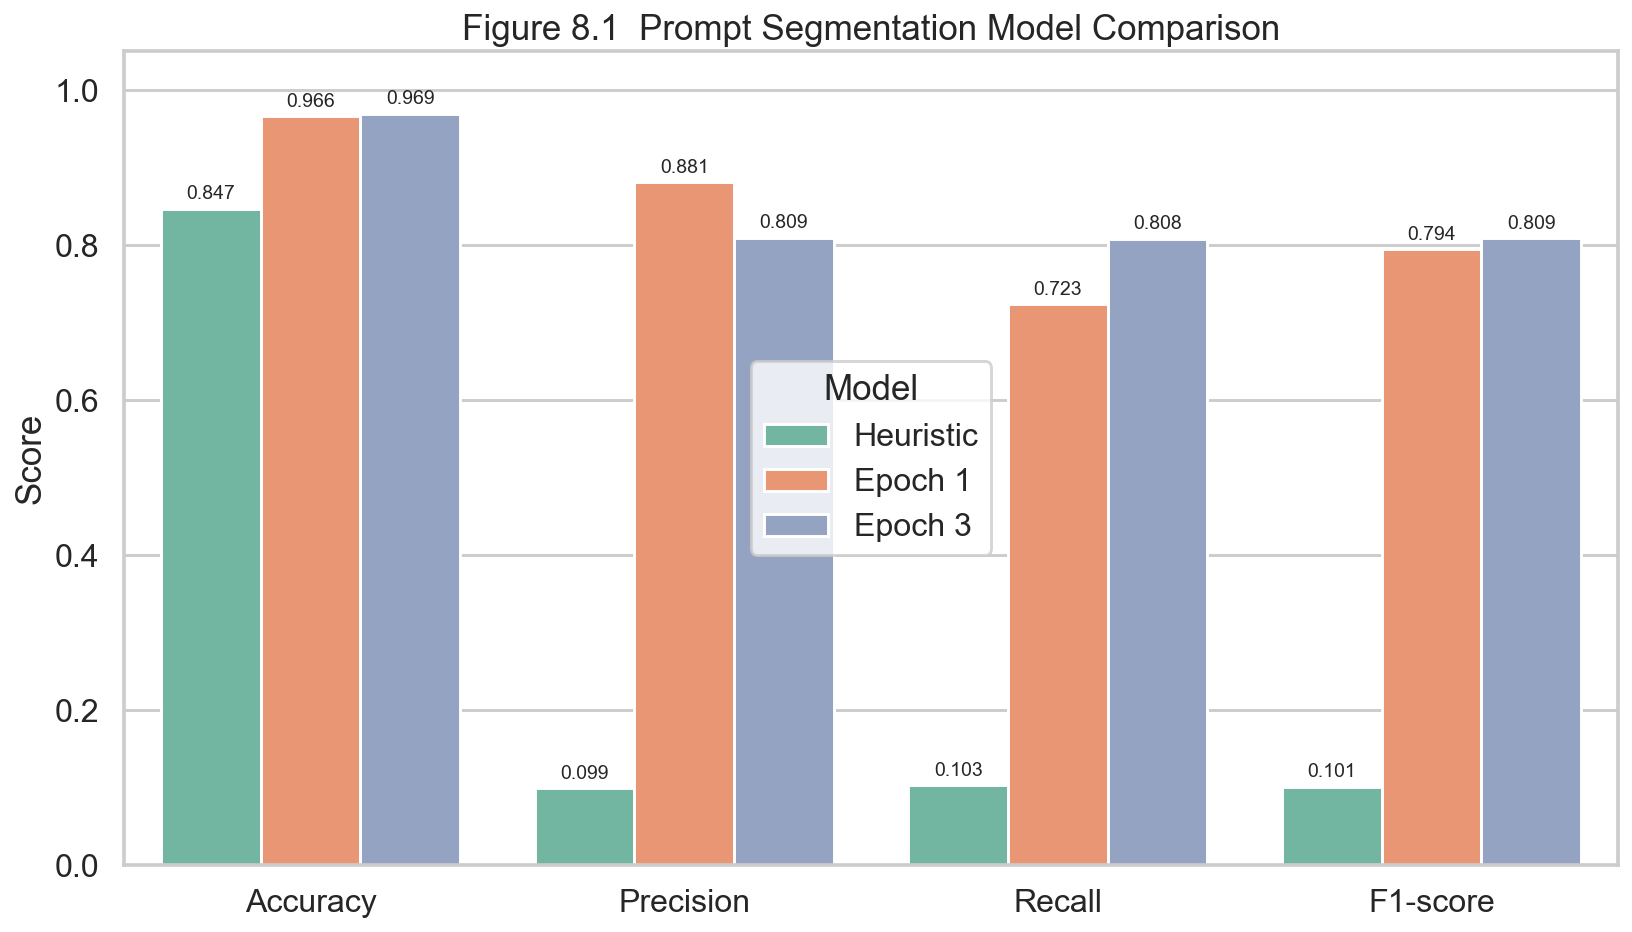

In [5]:
segmentation_df = pd.DataFrame([
    {'Model': 'Heuristic', 'Metric': 'Accuracy', 'Value': heuristic_segmenter['eval_accuracy']},
    {'Model': 'Heuristic', 'Metric': 'Precision', 'Value': heuristic_segmenter['eval_precision']},
    {'Model': 'Heuristic', 'Metric': 'Recall', 'Value': heuristic_segmenter['eval_recall']},
    {'Model': 'Heuristic', 'Metric': 'F1-score', 'Value': heuristic_segmenter['eval_f1']},
    {'Model': 'Epoch 1', 'Metric': 'Accuracy', 'Value': epoch1_segmenter['eval_accuracy']},
    {'Model': 'Epoch 1', 'Metric': 'Precision', 'Value': epoch1_segmenter['eval_precision']},
    {'Model': 'Epoch 1', 'Metric': 'Recall', 'Value': epoch1_segmenter['eval_recall']},
    {'Model': 'Epoch 1', 'Metric': 'F1-score', 'Value': epoch1_segmenter['eval_f1']},
    {'Model': 'Epoch 3', 'Metric': 'Accuracy', 'Value': epoch3_segmenter['eval_accuracy']},
    {'Model': 'Epoch 3', 'Metric': 'Precision', 'Value': epoch3_segmenter['eval_precision']},
    {'Model': 'Epoch 3', 'Metric': 'Recall', 'Value': epoch3_segmenter['eval_recall']},
    {'Model': 'Epoch 3', 'Metric': 'F1-score', 'Value': epoch3_segmenter['eval_f1']},
])

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=segmentation_df, x='Metric', y='Value', hue='Model', palette='Set2')
ax.set_title('Figure 8.1  Prompt Segmentation Model Comparison')
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.set_ylim(0, 1.05)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=10, padding=3)
plt.legend(title='Model')
plt.tight_layout()
plt.savefig(OUTPUT / 'figure-8-1-segmentation-model-comparison.png')
plt.show()


## 4. Figure 8.2: Segmentation Label Distribution

C:\Users\USER\AppData\Local\Temp\ipykernel_14460\1015440045.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=label_df, x='Ratio', y='Label', palette='Blues_r')


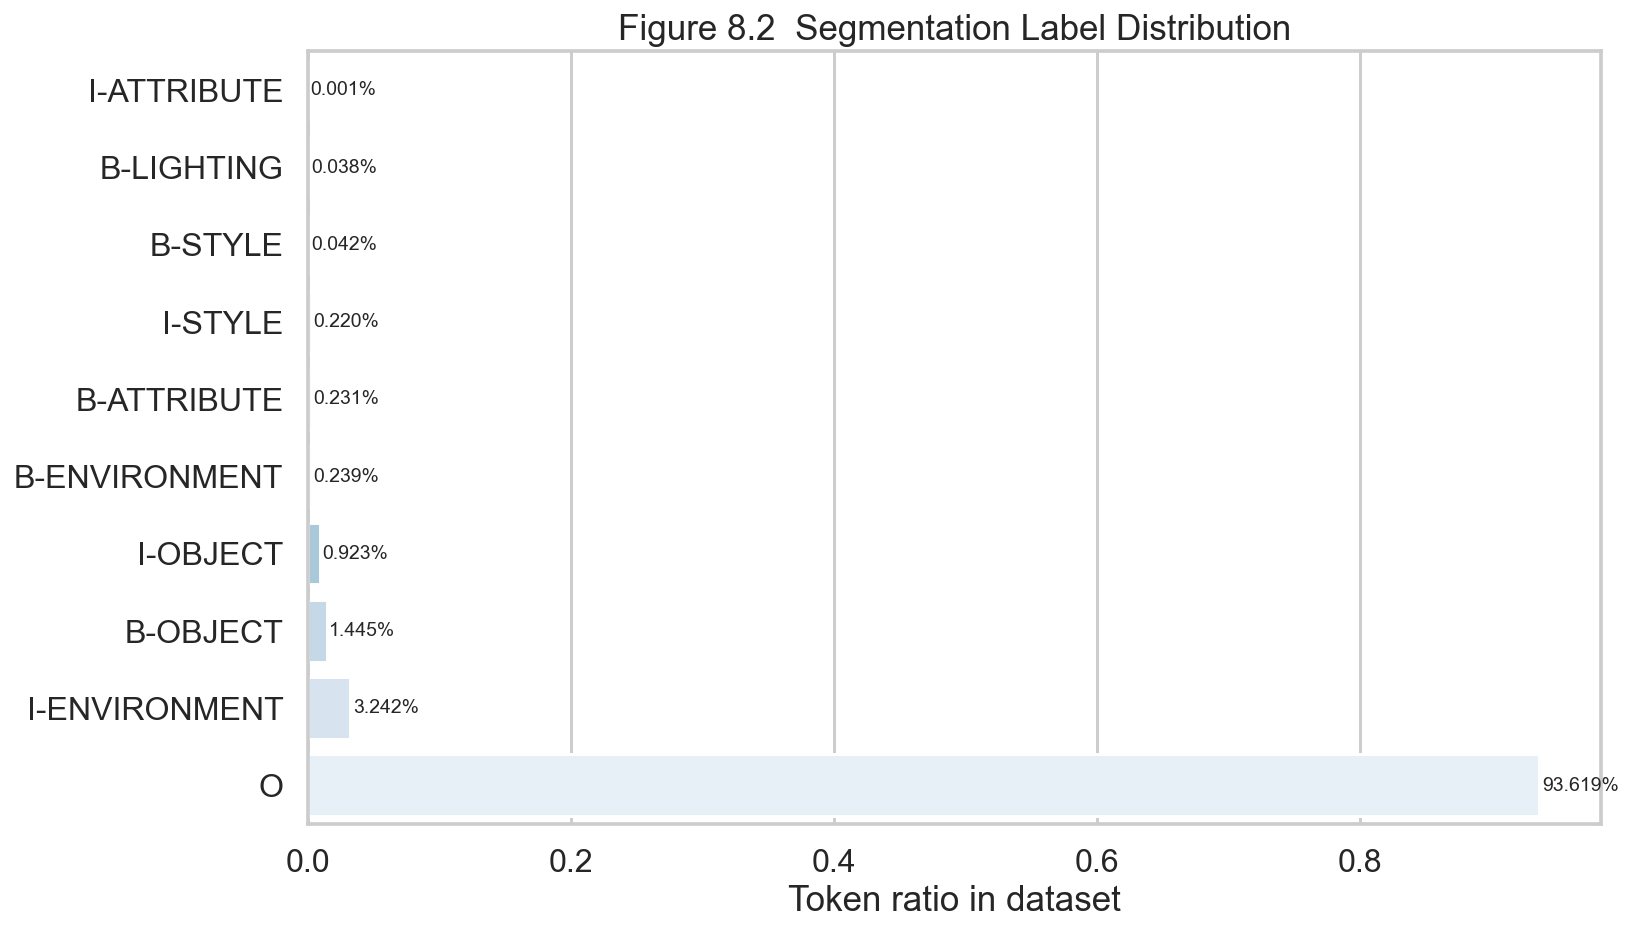

In [6]:
label_df = pd.DataFrame([
    {'Label': label, 'Ratio': value}
    for label, value in segmentation_labels['label_ratios'].items()
]).sort_values('Ratio', ascending=True)

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=label_df, x='Ratio', y='Label', palette='Blues_r')
ax.set_title('Figure 8.2  Segmentation Label Distribution')
ax.set_xlabel('Token ratio in dataset')
ax.set_ylabel('')
for i, row in enumerate(label_df.itertuples(index=False)):
    ax.text(row.Ratio + 0.002, i, f'{row.Ratio:.3%}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT / 'figure-8-2-segmentation-label-distribution.png')
plt.show()


## 5. Figure 8.3: Score Model MAE on the Large Labeled Test Split

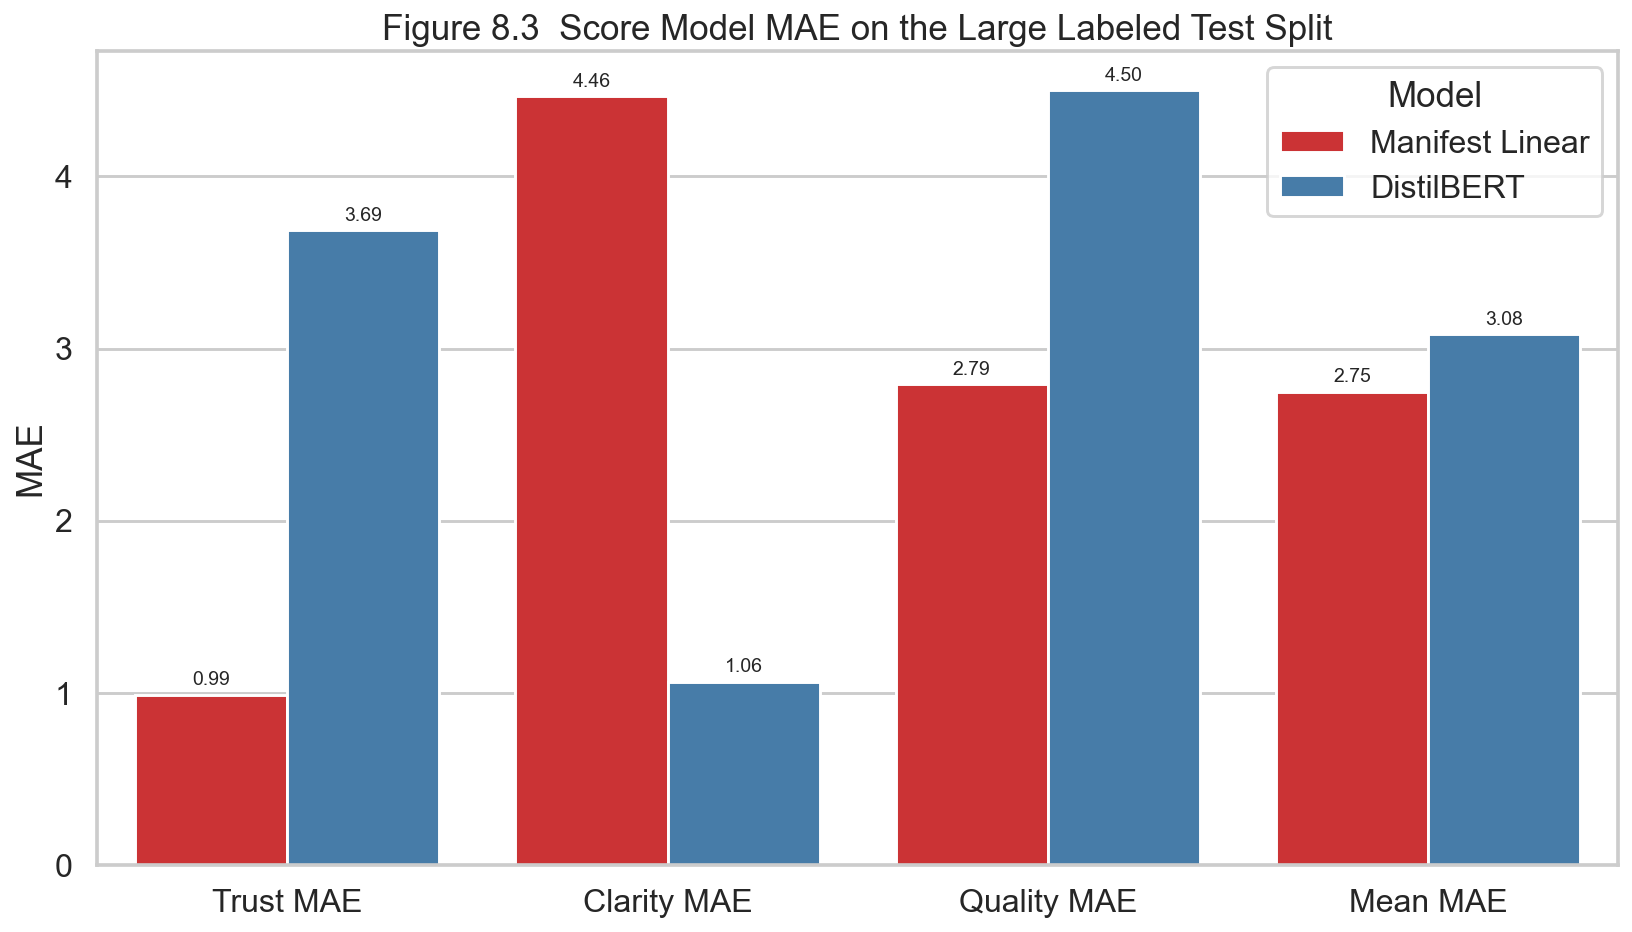

In [7]:
score_test_df = pd.DataFrame([
    {'Metric': 'Trust MAE', 'Model': 'Manifest Linear', 'Value': linear_test['trust_mae']},
    {'Metric': 'Clarity MAE', 'Model': 'Manifest Linear', 'Value': linear_test['clarity_mae']},
    {'Metric': 'Quality MAE', 'Model': 'Manifest Linear', 'Value': linear_test['quality_mae']},
    {'Metric': 'Mean MAE', 'Model': 'Manifest Linear', 'Value': linear_test['mae_mean']},
    {'Metric': 'Trust MAE', 'Model': 'DistilBERT', 'Value': distilbert_test['trust_mae']},
    {'Metric': 'Clarity MAE', 'Model': 'DistilBERT', 'Value': distilbert_test['clarity_mae']},
    {'Metric': 'Quality MAE', 'Model': 'DistilBERT', 'Value': distilbert_test['quality_mae']},
    {'Metric': 'Mean MAE', 'Model': 'DistilBERT', 'Value': distilbert_test['mae_mean']},
])

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=score_test_df, x='Metric', y='Value', hue='Model', palette='Set1')
ax.set_title('Figure 8.3  Score Model MAE on the Large Labeled Test Split')
ax.set_ylabel('MAE')
ax.set_xlabel('')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10, padding=3)
plt.tight_layout()
plt.savefig(OUTPUT / 'figure-8-3-score-model-mae-test.png')
plt.show()


## 6. Figure 8.4: Score Model MAE on the Reviewed Gold Set

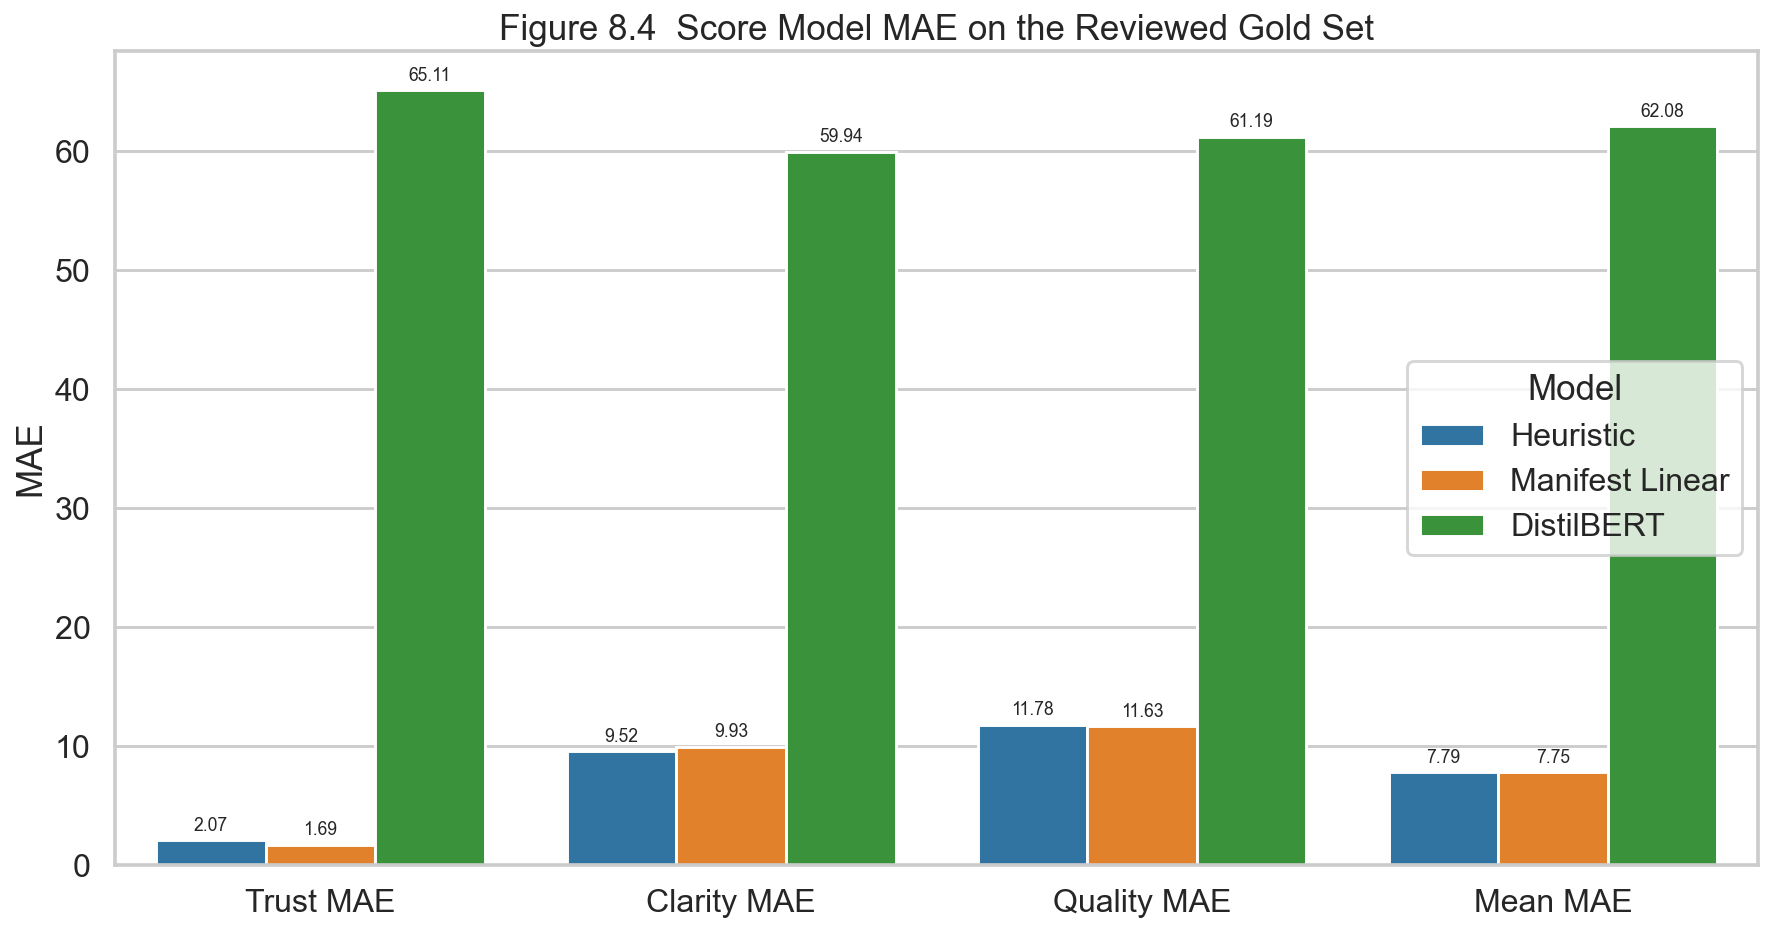

In [8]:
score_gold_df = pd.DataFrame([
    {'Metric': 'Trust MAE', 'Model': 'Heuristic', 'Value': heuristic_gold['trust_mae']},
    {'Metric': 'Clarity MAE', 'Model': 'Heuristic', 'Value': heuristic_gold['clarity_mae']},
    {'Metric': 'Quality MAE', 'Model': 'Heuristic', 'Value': heuristic_gold['quality_mae']},
    {'Metric': 'Mean MAE', 'Model': 'Heuristic', 'Value': heuristic_gold['mae_mean']},
    {'Metric': 'Trust MAE', 'Model': 'Manifest Linear', 'Value': linear_gold['trust_mae']},
    {'Metric': 'Clarity MAE', 'Model': 'Manifest Linear', 'Value': linear_gold['clarity_mae']},
    {'Metric': 'Quality MAE', 'Model': 'Manifest Linear', 'Value': linear_gold['quality_mae']},
    {'Metric': 'Mean MAE', 'Model': 'Manifest Linear', 'Value': linear_gold['mae_mean']},
    {'Metric': 'Trust MAE', 'Model': 'DistilBERT', 'Value': distilbert_gold['trust_mae']},
    {'Metric': 'Clarity MAE', 'Model': 'DistilBERT', 'Value': distilbert_gold['clarity_mae']},
    {'Metric': 'Quality MAE', 'Model': 'DistilBERT', 'Value': distilbert_gold['quality_mae']},
    {'Metric': 'Mean MAE', 'Model': 'DistilBERT', 'Value': distilbert_gold['mae_mean']},
])

plt.figure(figsize=(13, 7))
ax = sns.barplot(data=score_gold_df, x='Metric', y='Value', hue='Model', palette='tab10')
ax.set_title('Figure 8.4  Score Model MAE on the Reviewed Gold Set')
ax.set_ylabel('MAE')
ax.set_xlabel('')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9, padding=3)
plt.tight_layout()
plt.savefig(OUTPUT / 'figure-8-4-score-model-mae-gold.png')
plt.show()


## 7. Figure 8.5: Frontend Build Verification Summary

C:\Users\USER\AppData\Local\Temp\ipykernel_14460\1940755532.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=build_df, x='Value', y='Metric', palette='crest')


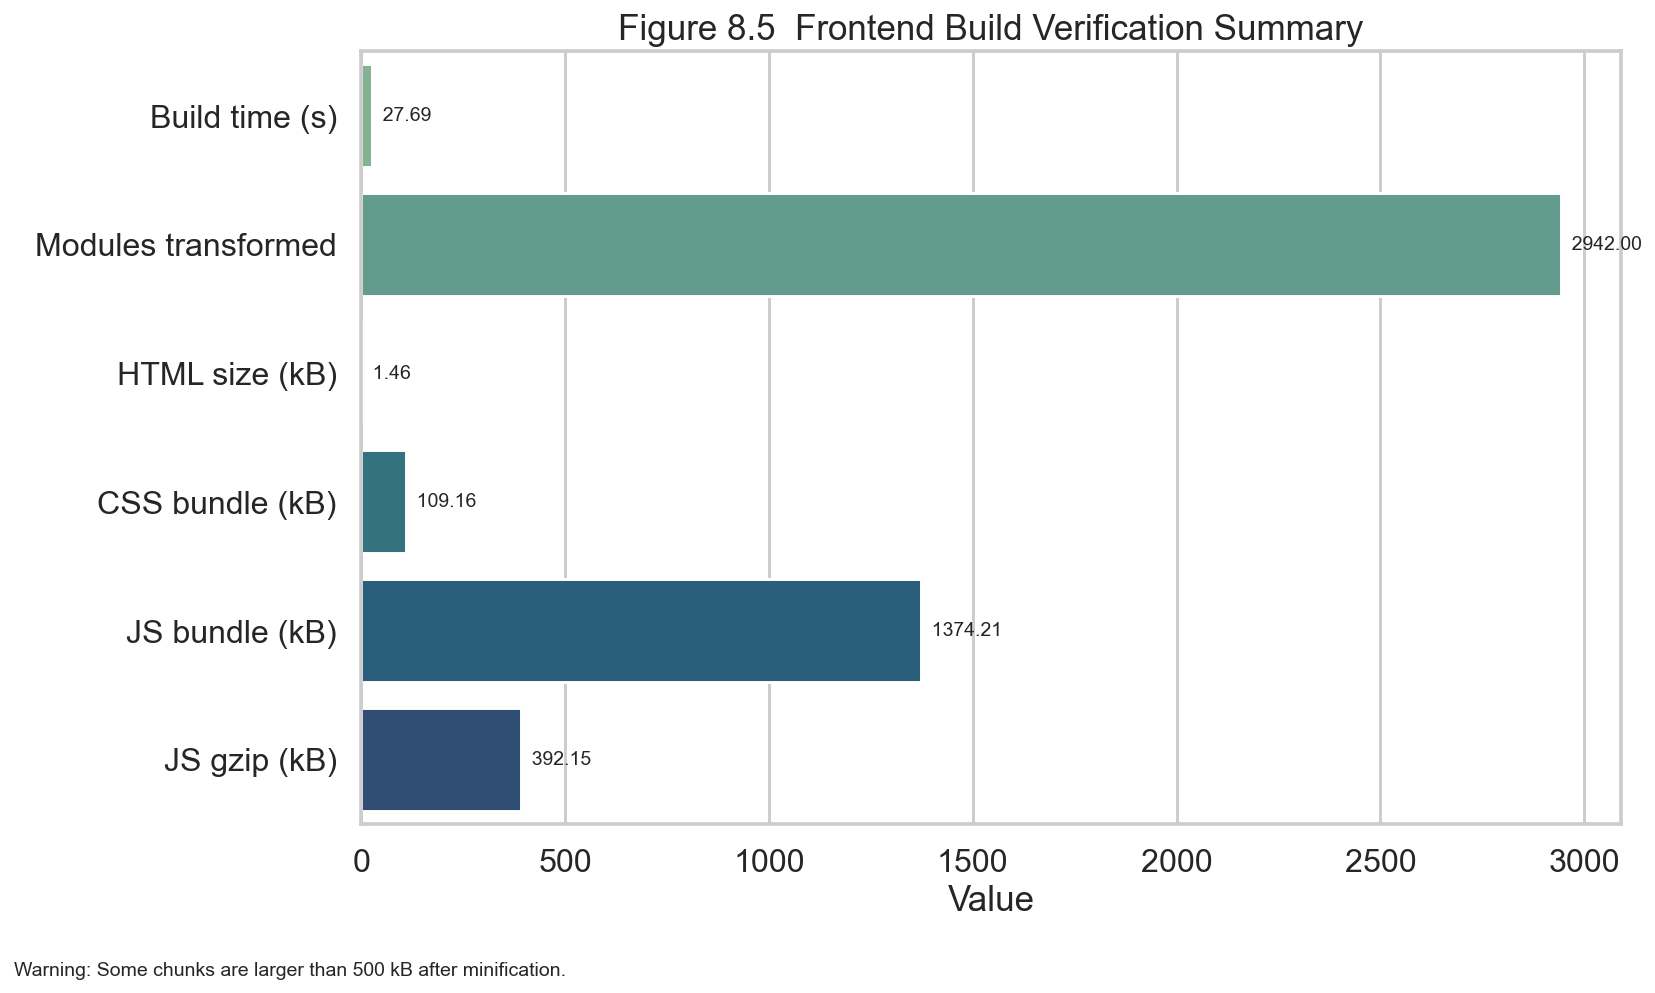

In [9]:
build_df = pd.DataFrame([
    {'Metric': 'Build time (s)', 'Value': build_check['build_time_seconds']},
    {'Metric': 'Modules transformed', 'Value': build_check['modules_transformed']},
    {'Metric': 'HTML size (kB)', 'Value': build_check['index_html_kb']},
    {'Metric': 'CSS bundle (kB)', 'Value': build_check['css_bundle_kb']},
    {'Metric': 'JS bundle (kB)', 'Value': build_check['js_bundle_kb']},
    {'Metric': 'JS gzip (kB)', 'Value': build_check['js_bundle_gzip_kb']},
])

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=build_df, x='Value', y='Metric', palette='crest')
ax.set_title('Figure 8.5  Frontend Build Verification Summary')
ax.set_xlabel('Value')
ax.set_ylabel('')
for i, row in enumerate(build_df.itertuples(index=False)):
    ax.text(row.Value, i, f'  {row.Value:.2f}' if isinstance(row.Value, float) else f'  {row.Value}', va='center', fontsize=10)
plt.figtext(0.01, -0.02, f"Warning: {build_check['warning']}", ha='left', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT / 'figure-8-5-frontend-build-summary.png')
plt.show()


## 8. Figure 8.7: Score Model Mean MAE — Large Split vs Gold Set

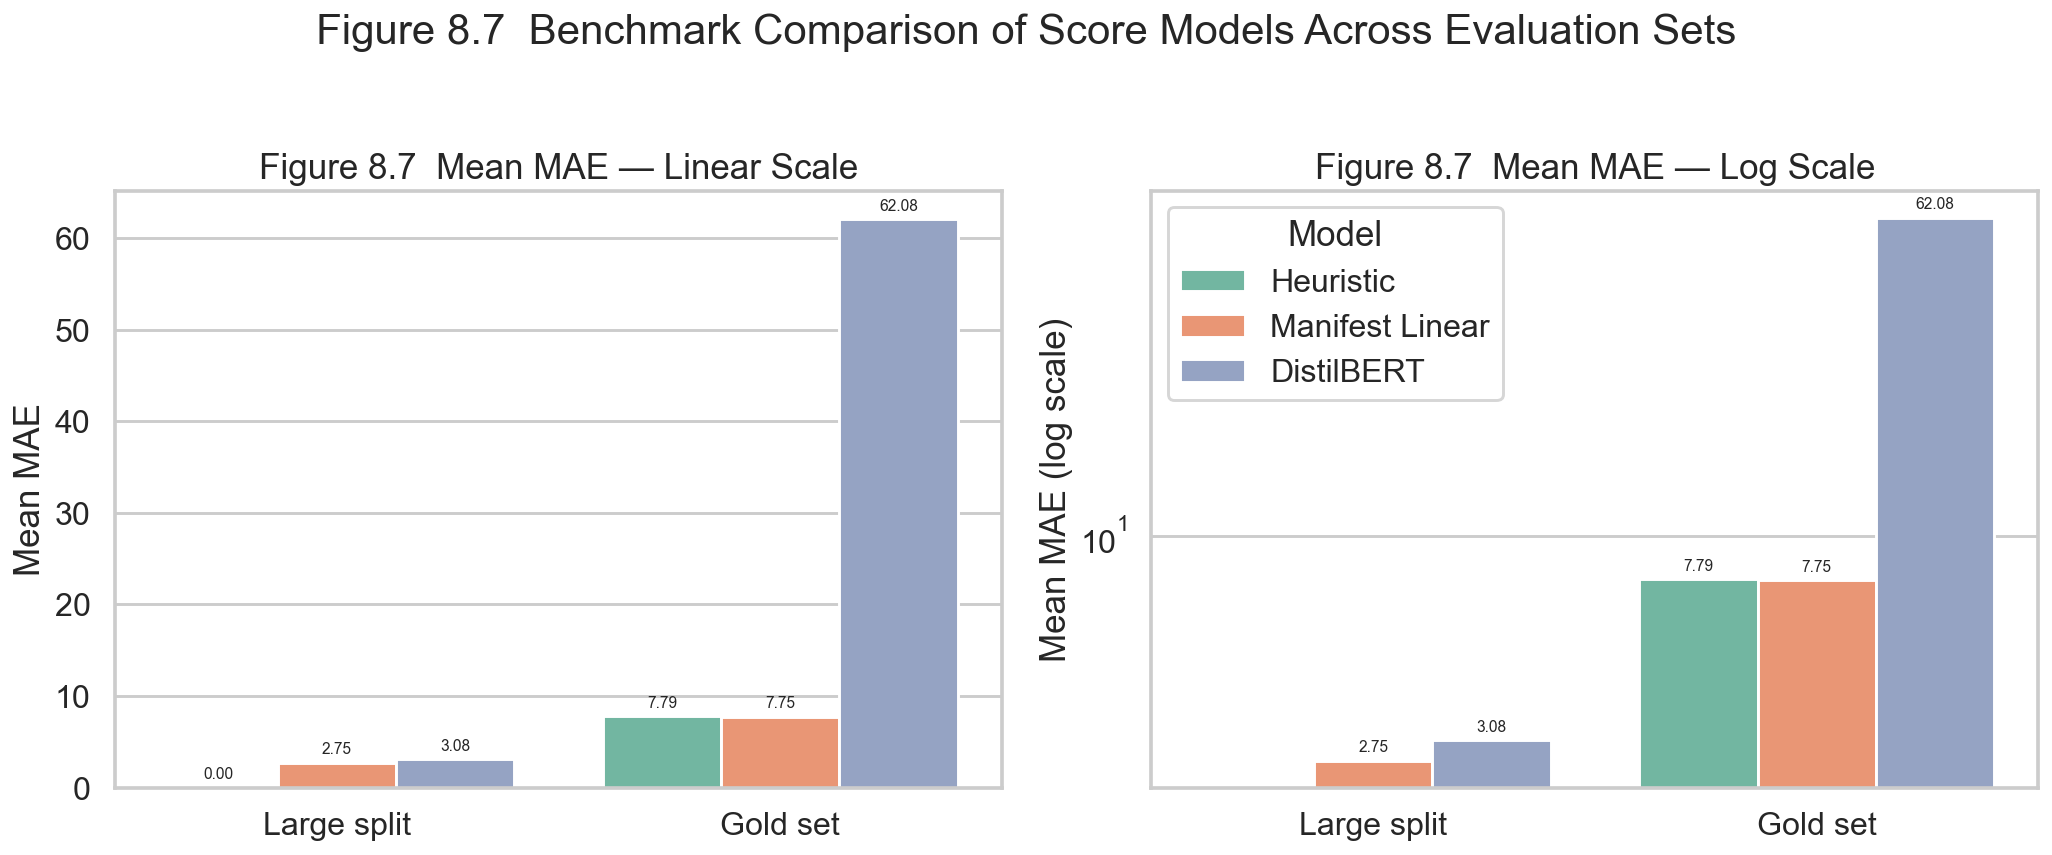

In [10]:
fig87_df = pd.DataFrame([
    {'Evaluation Set': 'Large split', 'Model': 'Heuristic', 'Mean MAE': heuristic_test['mae_mean']},
    {'Evaluation Set': 'Large split', 'Model': 'Manifest Linear', 'Mean MAE': linear_test['mae_mean']},
    {'Evaluation Set': 'Large split', 'Model': 'DistilBERT', 'Mean MAE': distilbert_test['mae_mean']},
    {'Evaluation Set': 'Gold set', 'Model': 'Heuristic', 'Mean MAE': heuristic_gold['mae_mean']},
    {'Evaluation Set': 'Gold set', 'Model': 'Manifest Linear', 'Mean MAE': linear_gold['mae_mean']},
    {'Evaluation Set': 'Gold set', 'Model': 'DistilBERT', 'Mean MAE': distilbert_gold['mae_mean']},
])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=fig87_df, x='Evaluation Set', y='Mean MAE', hue='Model', palette='Set2', ax=axes[0])
axes[0].set_title('Figure 8.7  Mean MAE — Linear Scale')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean MAE')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', fontsize=8, padding=3)

sns.barplot(data=fig87_df, x='Evaluation Set', y='Mean MAE', hue='Model', palette='Set2', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Figure 8.7  Mean MAE — Log Scale')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean MAE (log scale)')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', fontsize=8, padding=3)

axes[0].legend_.remove()
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, title='Model')
plt.suptitle('Figure 8.7  Benchmark Comparison of Score Models Across Evaluation Sets', y=1.03)
plt.tight_layout()
plt.savefig(OUTPUT / 'figure-8-7-score-model-mean-mae-large-vs-gold.png')
plt.show()


## 9. Figure 8.8: Score Model Mean RMSE Comparison

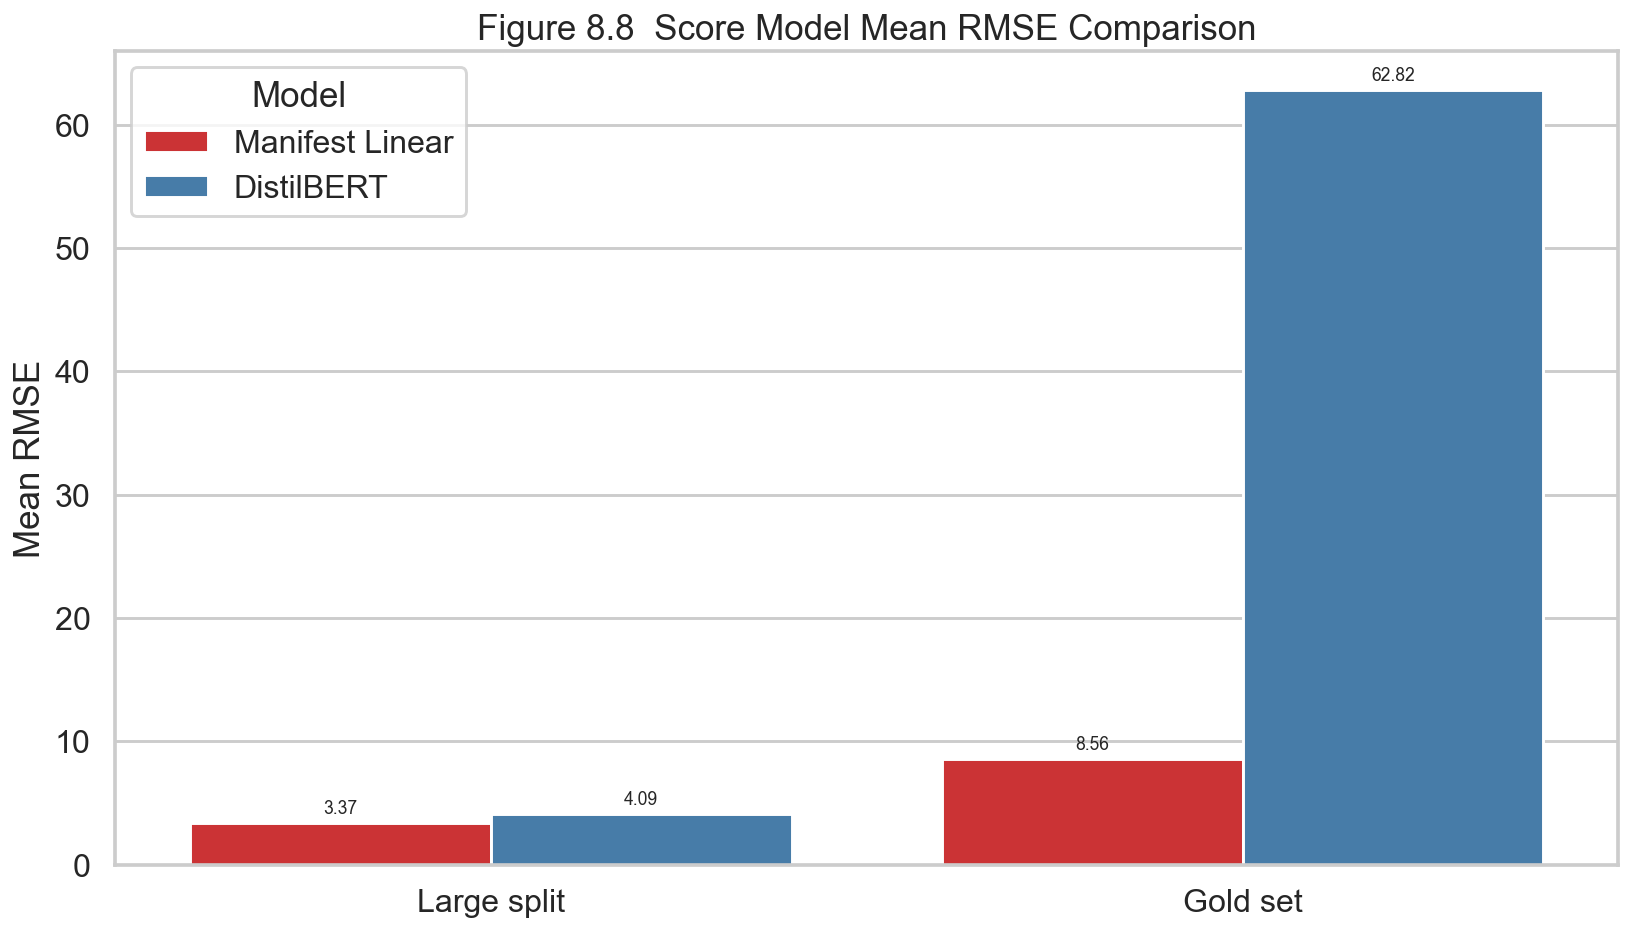

In [11]:
fig88_df = pd.DataFrame([
    {'Evaluation Set': 'Large split', 'Model': 'Manifest Linear', 'Mean RMSE': linear_test['rmse_mean']},
    {'Evaluation Set': 'Large split', 'Model': 'DistilBERT', 'Mean RMSE': distilbert_test['rmse_mean']},
    {'Evaluation Set': 'Gold set', 'Model': 'Manifest Linear', 'Mean RMSE': linear_gold['rmse_mean']},
    {'Evaluation Set': 'Gold set', 'Model': 'DistilBERT', 'Mean RMSE': distilbert_gold['rmse_mean']},
])

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=fig88_df, x='Evaluation Set', y='Mean RMSE', hue='Model', palette='Set1')
ax.set_title('Figure 8.8  Score Model Mean RMSE Comparison')
ax.set_xlabel('')
ax.set_ylabel('Mean RMSE')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9, padding=3)
plt.tight_layout()
plt.savefig(OUTPUT / 'figure-8-8-score-model-mean-rmse-comparison.png')
plt.show()


## 10. Figure 8.13: Functional Test Pass Rate Summary

C:\Users\USER\AppData\Local\Temp\ipykernel_14460\3189957594.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fig813_df, x='Status', y='Count', palette=colors, ax=axes[1])


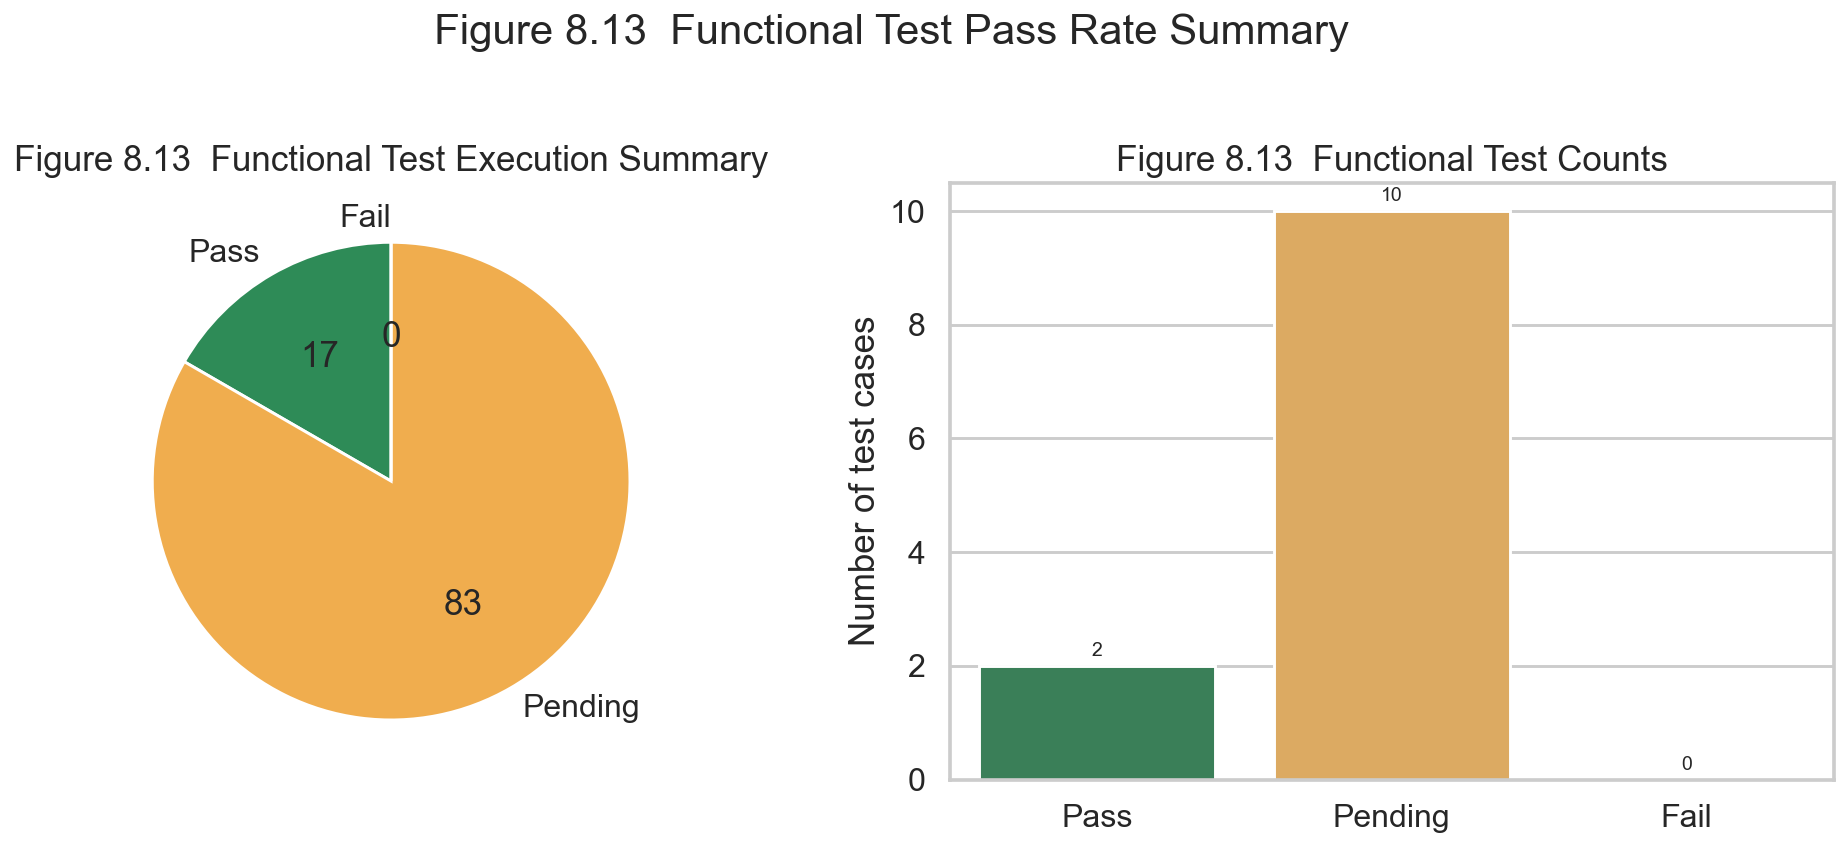

In [12]:
fig813_df = pd.DataFrame([
    {'Status': 'Pass', 'Count': 2},
    {'Status': 'Pending', 'Count': 10},
    {'Status': 'Fail', 'Count': 0},
])

colors = ['#2e8b57', '#f0ad4e', '#d9534f']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(
    fig813_df['Count'],
    labels=fig813_df['Status'],
    autopct='%1.0f',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)
axes[0].set_title('Figure 8.13  Functional Test Execution Summary')

sns.barplot(data=fig813_df, x='Status', y='Count', palette=colors, ax=axes[1])
axes[1].set_title('Figure 8.13  Functional Test Counts')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of test cases')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f', fontsize=10, padding=3)

plt.suptitle('Figure 8.13  Functional Test Pass Rate Summary', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT / 'figure-8-13-functional-test-pass-rate-summary.png')
plt.show()


## 11. Done

After running all cells, your PNG figures will be inside:

- `guidelines/figures/chapter8`

Then insert those `.png` files into the Chapter 8 report.